# Semantic Segmentation of Mechanical Parts with U-Net

## Project overview

This project tackles **pixel-level semantic segmentation** of mechanical parts in RGB images.

The model assigns one of **7 pixel classes** to every location:

- Background
- Hex nut
- Washer
- Bolt
- Ball bearing
- Spring
- O-ring

The dataset contains **2,000 labelled training images** and **500 unseen test images**, with images sized **384×384**.

### Approach

1. From-scratch **U-Net**
2. Random flips and 90° rotations for training augmentation
3. **Cross-Entropy + Soft Dice loss**
4. **Adam** with cosine-annealing learning-rate scheduling
5. Validation using **mean Dice**
6. **Test-Time Augmentation (TTA)** using six orientations
7. Connected-component cleanup
8. Run-Length Encoding (RLE) for submission

### Validation result

| Pipeline | Validation mean Dice |
|---|---:|
| U-Net | **0.9721** |
| U-Net + TTA + connected-component cleanup | **0.9740** |

The notebook below is the executed version of the project, cleaned for portfolio presentation.

> The competition dataset is not included in this repository. See the README for the expected local dataset layout.


In [1]:
# Semantic Segmentation — Portfolio Notebook
#
# Expected dataset layout:
# data/
# ├── metadata.csv
# ├── train/
# │   ├── train.csv
# │   ├── images/
# │   └── masks/
# └── test/
#     └── images/

import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings("ignore")

# Change this one path for your environment.
DATASET_ROOT = os.environ.get("SEGMENTATION_DATA_DIR", "data")

TRAIN_DIR      = f"{DATASET_ROOT}/train"
TRAIN_IMG_DIR  = f"{DATASET_ROOT}/train/images"
TRAIN_MASK_DIR = f"{DATASET_ROOT}/train/masks"
TRAIN_CSV      = f"{DATASET_ROOT}/train/train.csv"

TEST_DIR       = f"{DATASET_ROOT}/test"
TEST_IMG_DIR   = f"{DATASET_ROOT}/test/images"

METADATA_CSV   = f"{DATASET_ROOT}/metadata.csv"

OUT_DIR = os.environ.get("SEGMENTATION_OUTPUT_DIR", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

CLASSES = ["hex_nut", "washer", "bolt", "ball_bearing", "spring", "o_ring"]
CLASS_ID = {c: i + 1 for i, c in enumerate(CLASSES)}
ID_CLASS = {v: k for k, v in CLASS_ID.items()}
SIZE = 384
N_CLASSES = len(CLASSES) + 1  # six foreground classes + background

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
print("Classes:", CLASSES)
print("Dataset root:", DATASET_ROOT)


Using device: cuda
Classes: ['hex_nut', 'washer', 'bolt', 'ball_bearing', 'spring', 'o_ring']
Dataset root: /kaggle/input/competitions/nppe-1-dl-gen-ai-course-semantic-segmentation/Dataset


## The scoring rule (Dice) and the file-size trick (RLE)

### Dice, in code

We already described Dice in words above. Here it is as a function, used
**exactly as given in the competition rules** — we don't change a single
line of this, since it needs to match the grader precisely.

### Run-length encoding (RLE) — and its one big trap

A `384 × 384` mask has 147,456 pixels. Writing every single pixel's value
into a spreadsheet cell for 3,000 (image, class) pairs would make an
enormous file. Instead, the competition uses **run-length encoding (RLE)**:
instead of listing every pixel, we list `(start position, how many pixels in
a row are "on")` pairs. For example, `"1 3 10 5"` means "pixels 1, 2, 3 are
on, then pixels 10, 11, 12, 13, 14 are on".

**The trap:** pixels are numbered **column by column, top to bottom**, not
row by row (this is called *column-major* or *Fortran* order). Take this
tiny 4×4 example, where `X` marks a part pixel:

```
        col1  col2  col3  col4
row1     .     .     .     .
row2     X     .     .     .
row3     X     .     .     .
row4     .     .     .     .
```

Reading straight down column 1 first, then column 2, and so on, the pixels
are numbered:

```
column 1:  1  2  3  4
column 2:  5  6  7  8
column 3:  9 10 11 12
column 4: 13 14 15 16
```

Pixels 2 and 3 are the `X`s, and they're consecutive, so the correct RLE is
`"2 2"` (start at pixel 2, run for 2 pixels). If you built this the "normal"
row-by-row way instead, you'd get a completely different — and wrong —
answer, **without any error message**. Your file would still upload fine and
just silently score near zero. This is the single most common mistake in
competitions like this one, so we use the reference code below exactly as
provided, and we test it with a "round-trip" check (encode it, then decode
it, and make sure we get the original mask back) before trusting it.


In [2]:
def rle_encode(mask):
    """mask: a 384x384 boolean/0-1 array -> RLE string ("start length start length ...")."""
    px = np.asarray(mask, np.uint8).T.flatten()   # .T makes this column-by-column
    px = np.concatenate([[0], px, [0]])
    runs = np.where(px[1:] != px[:-1])[0] + 1
    runs[1::2] -= runs[::2]
    return " ".join(str(int(x)) for x in runs)


def rle_decode(rle, size=SIZE):
    """RLE string -> size x size uint8 array (0s and 1s)."""
    m = np.zeros(size * size, np.uint8)
    if not isinstance(rle, str) or not rle.strip():
        return m.reshape(size, size, order="F")
    a = np.asarray(rle.split(), np.int64)
    for s, l in zip(a[0::2], a[1::2]):
        m[s - 1: s - 1 + l] = 1
    return m.reshape(size, size, order="F")



def dice(pred, gt):
    """Dice score for ONE class, ONE image. pred and gt are boolean/0-1 masks."""
    p, g = int(np.sum(pred)), int(np.sum(gt))
    if g == 0:
        return 1.0 if p == 0 else 0.0
    if p == 0:
        return 0.0
    return 2.0 * float(np.logical_and(pred, gt).sum()) / (p + g)


def mean_dice(pred_labels, gt_labels):
    """The official metric: average Dice over every (image, class) pair."""
    scores = []
    for p, g in zip(pred_labels, gt_labels):
        for cid in range(1, len(CLASSES) + 1):
            scores.append(dice(p == cid, g == cid))
    return float(np.mean(scores))


# Quick self-test using the tiny 4x4 example from the explanation above.
_example = np.zeros((4, 4), np.uint8)
_example[1, 0] = 1  # row2, col1
_example[2, 0] = 1  # row3, col1
assert rle_encode(_example) == "2 2", "RLE example did not match the expected column-major answer!"
print("RLE worked example check: PASSED (encoded as '2 2', as expected)")


RLE worked example check: PASSED (encoded as '2 2', as expected)


## A hidden gotcha when reading `ImageId_ClassId`

Every row in `train.csv` (and in `sample_submission.csv`) uses a combined key
like `img_00000.png_hex_nut`, meaning "this row is about image
`img_00000.png`, class `hex_nut`". We need to split that string back into
its two parts.

The obvious way to do this is to split on the *last* underscore. That works
for a class like `washer` (`img_00000.png_washer` → image `img_00000.png`,
class `washer`) — but it **breaks** for three of our six classes, because
their names contain an underscore themselves: `hex_nut`, `ball_bearing`, and
`o_ring`. Splitting `img_00000.png_hex_nut` on the last underscore gives you
`img_00000.png_hex` and `nut` — silently wrong.

The fix: instead of guessing where to split, we check the string against the
list of class names we already know, and split at whichever one actually
matches the end of the string.


In [3]:
def split_image_class_id(s):
    for c in CLASSES:
        suffix = "_" + c
        if s.endswith(suffix):
            return s[: -len(suffix)], c
    raise ValueError(f"No known class suffix matched: {s}")

demo_ids = ["img_00000.png_hex_nut", "img_00000.png_washer", "img_00000.png_ball_bearing"]
print("naive s.rsplit('_', 1)  (WRONG for underscore-containing classes):")
for s in demo_ids:
    print(" ", s, "->", s.rsplit("_", 1))

print("\nsplit_image_class_id()  (correct):")
for s in demo_ids:
    print(" ", s, "->", split_image_class_id(s))


naive s.rsplit('_', 1)  (WRONG for underscore-containing classes):
  img_00000.png_hex_nut -> ['img_00000.png_hex', 'nut']
  img_00000.png_washer -> ['img_00000.png', 'washer']
  img_00000.png_ball_bearing -> ['img_00000.png_ball', 'bearing']

split_image_class_id()  (correct):
  img_00000.png_hex_nut -> ('img_00000.png', 'hex_nut')
  img_00000.png_washer -> ('img_00000.png', 'washer')
  img_00000.png_ball_bearing -> ('img_00000.png', 'ball_bearing')


In [4]:
meta = pd.read_csv(METADATA_CSV)
train_df = pd.read_csv(TRAIN_CSV)

# Split "img_00000.png_hex_nut" into its ImageId and Class columns.
parsed = train_df["ImageId_ClassId"].apply(split_image_class_id)
train_df["ImageId"] = parsed.apply(lambda t: t[0])
train_df["Class"] = parsed.apply(lambda t: t[1])

# A fast lookup table: (ImageId, Class) -> EncodedPixels (the RLE string).
rle_lookup = {(r.ImageId, r.Class): r.EncodedPixels for r in train_df.itertuples()}

print(meta["split"].value_counts())
print("\nClasses found after parsing train.csv:", sorted(train_df["Class"].unique()))
assert sorted(train_df["Class"].unique()) == sorted(CLASSES), "Class parsing is still wrong!"

# Round-trip sanity check on one real training mask, as the rules recommend
# doing before trusting any RLE code.
sample_rle = train_df.iloc[0]["EncodedPixels"]
m = rle_decode(sample_rle)
assert np.array_equal(rle_decode(rle_encode(m)), m.astype(np.uint8))
print("RLE round-trip sanity check on a real mask: PASSED")


split
train    2000
test      500
Name: count, dtype: int64

Classes found after parsing train.csv: ['ball_bearing', 'bolt', 'hex_nut', 'o_ring', 'spring', 'washer']
RLE round-trip sanity check on a real mask: PASSED


## Loading the real mask files (and a second gotcha)

Every training image has a matching mask file in `train/masks/`, with the
*same filename* as its photo. A mask is a grayscale image where every pixel
just stores a small number: `0` for background, `1` for `hex_nut`, `2` for
`washer`, and so on up to `6` for `o_ring`.

To make masks easy for a *person* to look at in an image viewer, they also
have a colour palette attached (so class `3` might display as a shade of
blue, for example). This is where the second big gotcha lives: if you open a
mask and call `.convert("RGB")` on it, Python helpfully converts it *using
that colour palette* — handing you RGB colours instead of the class numbers
`0`–`6` you actually need. This is the single most common data-loading
mistake in this type of competition. The fix is simple: just load the file
with `np.array(Image.open(path))` and **never** call `.convert("RGB")` on a
mask.

We also double-check below that reading the mask file directly gives us the
exact same result as rebuilding the mask from `train.csv`'s RLE rows — this
confirms both loading paths (file-based and RLE-based) agree with each
other.


In [5]:
def load_label_from_disk(img_id, split="train"):
    mask_dir = TRAIN_MASK_DIR  # only training images have mask files
    return np.array(Image.open(f"{mask_dir}/{img_id}"))


def build_label_map_from_rle(img_id):
    """Rebuilds the same 0-6 label map, but from train.csv's RLE rows instead
    of the mask PNG. Used only as a cross-check in the cell below."""
    lab = np.zeros((SIZE, SIZE), np.uint8)
    for c in CLASSES:
        rle = rle_lookup.get((img_id, c), "")
        if rle:
            lab[rle_decode(rle).astype(bool)] = CLASS_ID[c]
    return lab


# Confirm the mask file and the train.csv RLE rows agree, for a real image.
_test_id = sorted(meta[meta.split == "train"].id)[0]
assert np.array_equal(load_label_from_disk(_test_id), build_label_map_from_rle(_test_id))
print(f"Mask file and train.csv agree with each other for '{_test_id}': PASSED")
print("Unique pixel values in one real mask:", np.unique(load_label_from_disk(_test_id)))


Mask file and train.csv agree with each other for 'img_00000.png': PASSED
Unique pixel values in one real mask: [0 1 2 3 4 5 6]


## Splitting our training images into "fit" and "validation" sets

In [6]:
def stratified_split(meta_df, val_frac=0.15, seed=0):
    """Splits training image ids into (fit_ids, val_ids), keeping the mix of
    background material and clutter level (n_parts) similar in both groups."""
    tr = meta_df[meta_df.split == "train"].copy()
    tr["n_parts_bucket"] = pd.cut(tr["n_parts"], bins=[5, 7, 9, 11], labels=["low", "mid", "high"])
    tr["stratum"] = tr["background"].astype(str) + "_" + tr["n_parts_bucket"].astype(str)

    rng = np.random.default_rng(seed)
    val_ids = []
    for stratum, grp in tr.groupby("stratum", observed=True):
        ids = grp["id"].tolist()
        n_val = max(1, round(len(ids) * val_frac))
        val_ids.extend(rng.choice(ids, n_val, replace=False))
    val_ids = sorted(set(val_ids))
    fit_ids = sorted(set(tr["id"]) - set(val_ids))
    return fit_ids, val_ids


FIT_IDS, VAL_IDS = stratified_split(meta)
print(f"Training on {len(FIT_IDS)} images, validating on {len(VAL_IDS)} images")

# Confirm the background-material mix in validation looks balanced.
print("\nBackground mix in the validation set:")
print(meta[meta.id.isin(VAL_IDS)]["background"].value_counts(normalize=True).round(3))


Training on 1699 images, validating on 301 images

Background mix in the validation set:
background
brushed_metal    0.256
woven_fabric     0.249
concrete         0.249
wood             0.246
Name: proportion, dtype: float64


## Teaching PyTorch how to load our images (the `Dataset` class)

PyTorch expects data to come from a `Dataset` object that knows two things:
"how many examples are there?" (`__len__`) and "give me example number `i`"
(`__getitem__`). We write a small class, `PartsDataset`, that:

1. Opens the image file and scales its pixel values from the usual `0–255`
   range down to `0.0–1.0` (neural networks train more smoothly on small
   numbers).
2. For training images, also loads the matching label mask.
3. Optionally applies **data augmentation**: small random changes to the
   image (and its mask, to match) such as flipping it left-right, flipping
   it top-bottom, or rotating it 90/180/270 degrees. Since our hardware
   parts can be scattered in *any* orientation on the bench, teaching the
   model that a bolt is still a bolt no matter which way it's rotated helps
   it generalise better, instead of just memorising exact orientations from
   the training photos.

We only turn augmentation on for the training data — the validation and
test images are always shown to the model exactly as they are, since we want
our validation score to reflect real, un-augmented performance.


In [7]:
class PartsDataset(Dataset):
    """Loads real image/mask files from disk.
    img_ids: a list of filenames, e.g. ['img_00000.png', 'img_00001.png', ...].
    """
    def __init__(self, img_ids, split="train", augment=False):
        self.img_ids = img_ids
        self.split = split
        self.augment = augment

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_dir = TRAIN_IMG_DIR if self.split == "train" else TEST_IMG_DIR
        img = np.array(Image.open(f"{img_dir}/{img_id}").convert("RGB"))
        img = img.astype(np.float32) / 255.0

        if self.split == "train":
            lab = load_label_from_disk(img_id, split="train").astype(np.int64)
        else:
            lab = np.zeros((SIZE, SIZE), np.int64)  # test images have no label; kept for a consistent return shape

        if self.augment:
            if np.random.rand() < 0.5:                      # flip left-right
                img, lab = img[:, ::-1].copy(), lab[:, ::-1].copy()
            if np.random.rand() < 0.5:                      # flip top-bottom
                img, lab = img[::-1, :].copy(), lab[::-1, :].copy()
            k = np.random.randint(0, 4)                      # rotate 0/90/180/270 degrees
            if k:
                img, lab = np.rot90(img, k).copy(), np.rot90(lab, k).copy()

        img = torch.from_numpy(img).permute(2, 0, 1).float()   # (3, H, W) -- channels first, as PyTorch expects
        lab = torch.from_numpy(lab).long()                      # (H, W), values 0-6
        return img, lab, img_id


## The model: a U-Net

Now for the actual "brain" that will learn to segment our images: a
**U-Net**. The name comes from the shape of its diagram — it looks like the
letter U. Here's the idea in plain language:

- **The left (downward) half — the encoder.** The network repeatedly shrinks
  the image down (like zooming out) while learning more and more *abstract*
  information at each step: first simple things like edges and colours, then
  shapes, then eventually "this whole region looks like a bolt". Shrinking
  the image lets the network "see" a bigger area at once with each step.
- **The right (upward) half — the decoder.** The network then grows the
  image back up (zooming back in) to its original size, step by step, so it
  can finally say which class *each individual pixel* belongs to.
- **Skip connections — the useful shortcut.** Shrinking an image loses fine
  detail (thin spring coils, exact edges) the same way zooming a photo out
  loses detail. To fix this, at every "zoom back in" step, the U-Net is
  handed a direct copy of the matching "zoom out" step's information, so it
  can combine the big-picture understanding with the fine detail it would
  otherwise have lost. This is what "skip connections" (the `torch.cat(...)`
  calls below) are for.

We build this U-Net completely from scratch (no pretrained weights needed) —
it has 4 shrinking steps, a middle "bottleneck", and 4 growing steps, with a
skip connection at every matching resolution.


In [8]:
def conv_block(c_in, c_out):
    """Two 3x3 convolutions in a row, each followed by batch-norm and a ReLU
    activation. This is the basic repeated building block of a U-Net."""
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
    )


class UNet(nn.Module):
    """A from-scratch U-Net: 4 downsampling ("zoom out") stages, a bottleneck,
    then 4 upsampling ("zoom in") stages, with a skip connection at every
    matching resolution."""
    def __init__(self, in_ch=3, n_classes=N_CLASSES, base=32):
        super().__init__()
        # Encoder (zooming out)
        self.enc1 = conv_block(in_ch, base)
        self.enc2 = conv_block(base, base * 2)
        self.enc3 = conv_block(base * 2, base * 4)
        self.enc4 = conv_block(base * 4, base * 8)
        self.bottleneck = conv_block(base * 8, base * 16)
        self.pool = nn.MaxPool2d(2)   # halves the image size each time it's applied

        # Decoder (zooming back in), each with a skip connection from the encoder
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, 2, stride=2)
        self.dec4 = conv_block(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = conv_block(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = conv_block(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = conv_block(base * 2, base)

        # Final 1x1 convolution: turns features into one score per class, per pixel
        self.out = nn.Conv2d(base, n_classes, 1)

    def forward(self, x):
        # Zoom out, remembering each stage's output for later (the skip connections)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        # Zoom back in, combining with the remembered encoder outputs at each step
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)   # shape: (batch, N_CLASSES, height, width) -- raw scores ("logits")


# A quick shape check: feed in a fake image and confirm the output shape makes sense.
_dummy = torch.zeros(1, 3, SIZE, SIZE)
_out_shape = UNet()(_dummy).shape
print("UNet output shape for one 384x384 image:", tuple(_out_shape), "-- (batch, classes, height, width)")


UNet output shape for one 384x384 image: (1, 7, 384, 384) -- (batch, classes, height, width)


## The loss function: 

While training, the model needs a single number that tells it "how wrong was
your last guess", so it can adjust itself to do better next time. We combine
**two** different ways of measuring wrongness:

1. **Cross-entropy loss** — the standard way to measure "did you pick the
   right class for each pixel". It looks at each pixel independently.
2. **Soft Dice loss** — a *smooth, trainable* version of the exact Dice
   metric we're actually graded on. Since Dice cares about the *overlap* of
   whole regions (not just individual pixels), directly including it in
   training nudges the model to optimise for the thing we actually care
   about, especially helping with small or thin classes like springs and
   o-rings that cross-entropy alone tends to under-value.

We use a 50/50 blend of the two.


In [9]:
def soft_dice_loss(logits, target, eps=1e-6):
    """A differentiable (trainable) version of the Dice metric, averaged over
    all classes including background. target: (B, H, W) int64 labels 0..N_CLASSES-1."""
    probs = F.softmax(logits, dim=1)
    target_onehot = F.one_hot(target, N_CLASSES).permute(0, 3, 1, 2).float()
    dims = (0, 2, 3)
    intersection = (probs * target_onehot).sum(dims)
    union = probs.sum(dims) + target_onehot.sum(dims)
    dice_per_class = (2 * intersection + eps) / (union + eps)
    return 1 - dice_per_class.mean()


def combined_loss(logits, target, dice_weight=0.5):
    """A 50/50 blend of ordinary cross-entropy and soft Dice loss."""
    ce = F.cross_entropy(logits, target)
    dice_l = soft_dice_loss(logits, target)
    return (1 - dice_weight) * ce + dice_weight * dice_l


## The training loop

- **Epoch** — one complete pass through *all* of the training images.
  We train for 25 epochs, meaning the model sees every training image 25
  times in total (with different random flips/rotations each time, thanks to
  our augmentation).
- **Batch** — instead of updating the model after every single image, we
  group images into small batches (16 at a time here) and update the model
  once per batch. This is both faster and gives smoother, more stable
  updates.
- **Optimizer (Adam)** — the algorithm that actually adjusts the model's
  internal numbers ("weights") to reduce the loss, batch by batch.
- **Learning-rate scheduler (cosine annealing)** — controls *how big* each
  adjustment step is. We start with bigger steps and smoothly shrink them
  over the 25 epochs, so the model makes fast progress early on and then
  fine-tunes gently near the end instead of overshooting a good solution.
- **Keeping the best epoch** — after every epoch we check the model's Dice
  score on our validation set (the images it never trains on) and keep a
  saved copy of whichever epoch scored highest — a little like keeping your
  best attempt out of several practice runs, in case a later epoch happens
  to get slightly worse (which can occasionally happen).


In [10]:
@torch.no_grad()
def evaluate(model, loader):
    """Runs the model on a DataLoader (no training, no augmentation) and
    returns the mean_dice score against the true labels."""
    model.eval()
    preds, gts = [], []
    for imgs, labs, _ in loader:
        imgs = imgs.to(DEVICE)
        logits = model(imgs)
        pred = logits.argmax(1).cpu().numpy()   # pick the highest-scoring class at each pixel
        for p, g in zip(pred, labs.numpy()):
            preds.append(p.astype(np.uint8))
            gts.append(g.astype(np.uint8))
    return mean_dice(preds, gts)


def train_unet(fit_ids, val_ids, epochs=25, batch_size=16, lr=1e-3):
    train_ds = PartsDataset(fit_ids, split="train", augment=True)
    val_ds = PartsDataset(val_ids, split="train", augment=False)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    model = UNet().to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    best_dice, best_state = -1.0, None
    for epoch in range(epochs):
        model.train()
        running = 0.0
        for imgs, labs, _ in train_loader:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            opt.zero_grad()
            loss = combined_loss(model(imgs), labs)
            loss.backward()
            opt.step()
            running += loss.item() * imgs.size(0)
        sched.step()

        val_dice = evaluate(model, val_loader)
        print(f"epoch {epoch+1:2d}/{epochs}  train_loss {running/len(train_ds):.4f}  val_dice {val_dice:.4f}")
        if val_dice > best_dice:
            best_dice, best_state = val_dice, {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, best_dice


In [11]:
model, best_val_dice = train_unet(FIT_IDS, VAL_IDS, epochs=25, batch_size=16, lr=1e-3)
print(f"\nBest local validation mean Dice (U-Net alone): {best_val_dice:.4f}")

torch.save(model.state_dict(), f"{OUT_DIR}/unet_final.pt")
print(f"Saved model weights to {OUT_DIR}/unet_final.pt")

epoch  1/25  train_loss 0.8209  val_dice 0.3556
epoch  2/25  train_loss 0.3961  val_dice 0.6121
epoch  3/25  train_loss 0.1953  val_dice 0.8288
epoch  4/25  train_loss 0.1198  val_dice 0.8788
epoch  5/25  train_loss 0.0942  val_dice 0.8583
epoch  6/25  train_loss 0.0767  val_dice 0.9276
epoch  7/25  train_loss 0.0645  val_dice 0.9177
epoch  8/25  train_loss 0.0549  val_dice 0.9455
epoch  9/25  train_loss 0.0491  val_dice 0.9377
epoch 10/25  train_loss 0.0459  val_dice 0.9272
epoch 11/25  train_loss 0.0416  val_dice 0.9481
epoch 12/25  train_loss 0.0383  val_dice 0.9598
epoch 13/25  train_loss 0.0386  val_dice 0.9622
epoch 14/25  train_loss 0.0353  val_dice 0.9641
epoch 15/25  train_loss 0.0341  val_dice 0.9655
epoch 16/25  train_loss 0.0326  val_dice 0.9672
epoch 17/25  train_loss 0.0311  val_dice 0.9686
epoch 18/25  train_loss 0.0306  val_dice 0.9695
epoch 19/25  train_loss 0.0294  val_dice 0.9696
epoch 20/25  train_loss 0.0288  val_dice 0.9707
epoch 21/25  train_loss 0.0285  val_dice

## Test-Time Augmentation (TTA): asking the model 6 times

Once the model is trained, we can still squeeze out a little more accuracy
*without* any further training, using a trick called **Test-Time
Augmentation**. The idea: show the model the same image 6 different ways —
as-is, flipped horizontally, flipped vertically, and rotated 90°/180°/270° —
undo each transformation on the model's answer, and then **average** all 6
answers together.

Why does this help? Each individual view might make the model slightly more
or less confident in different spots, almost like getting a second opinion.
Averaging several honest opinions together tends to cancel out random
mistakes and land closer to the truth — the same reasoning behind asking a
few people the same question and going with the majority view, rather than
trusting a single answer.

In our earlier experiments, this bumped the validation score from 0.9718 to
0.9740 — a small but real improvement, and effectively free since it needs
no extra training.


In [12]:
def tta_predict(model, img_tensor):
    """img_tensor: (1, 3, H, W) on DEVICE. Returns the averaged softmax
    probabilities (1, N_CLASSES, H, W) across 6 flipped/rotated views."""
    model.eval()
    transforms = [
        (lambda x: x,                                  lambda x: x),                                   # identity
        (lambda x: torch.flip(x, [3]),                 lambda x: torch.flip(x, [3])),                   # horizontal flip
        (lambda x: torch.flip(x, [2]),                 lambda x: torch.flip(x, [2])),                   # vertical flip
        (lambda x: torch.rot90(x, 1, [2, 3]),           lambda x: torch.rot90(x, -1, [2, 3])),           # rotate 90
        (lambda x: torch.rot90(x, 2, [2, 3]),           lambda x: torch.rot90(x, -2, [2, 3])),           # rotate 180
        (lambda x: torch.rot90(x, 3, [2, 3]),           lambda x: torch.rot90(x, -3, [2, 3])),           # rotate 270
    ]
    probs_sum = None
    with torch.no_grad():
        for forward_transform, undo_transform in transforms:
            logits = model(forward_transform(img_tensor))
            probs = undo_transform(F.softmax(logits, dim=1))
            probs_sum = probs if probs_sum is None else probs_sum + probs
    return probs_sum / len(transforms)

## Cleaning up tiny noise specks

Even a well-trained model occasionally predicts a handful of stray pixels
somewhere that don't belong to any real part — a little bit of visual noise.
Since we know from the dataset specification that real parts are always
reasonably sized (never just a couple of stray pixels), we can safely remove
any predicted blob smaller than 15 pixels for each class. This is a small,
conservative cleanup — the threshold is kept low on purpose so we don't
accidentally erase genuinely thin, real structures like a spring's coil or a
washer's rim.


In [13]:
def clean_small_components(label_map, min_area=15):
    """Removes connected blobs smaller than min_area pixels, one class at a
    time, leaving everything else untouched."""
    cleaned = label_map.copy()
    for cid in range(1, N_CLASSES):
        mask = (label_map == cid).astype(np.uint8)
        n, blob_labels, stats, _ = cv2.connectedComponentsWithStats(mask, 8)
        for i in range(1, n):
            if stats[i, cv2.CC_STAT_AREA] < min_area:
                cleaned[blob_labels == i] = 0
    return cleaned

## scoring our *full* final pipeline

Before we touch the real test images, let's confirm that our complete final
pipeline — the trained U-Net, **plus** TTA, **plus** the small-blob cleanup —
really does score at least as well on our validation set as it did in our
earlier experiments (0.9740). This is our last chance to catch a mistake
while we still have the correct answers (the validation masks) to compare
against.


In [14]:
@torch.no_grad()
def evaluate_final_pipeline(model, ids):
    preds, gts = [], []
    for img_id in ids:
        img = np.array(Image.open(f"{TRAIN_IMG_DIR}/{img_id}").convert("RGB")).astype(np.float32) / 255.0
        t = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
        probs = tta_predict(model, t)
        pred = probs.argmax(1).squeeze(0).cpu().numpy().astype(np.uint8)
        pred = clean_small_components(pred)
        preds.append(pred)
        gts.append(load_label_from_disk(img_id, split="train"))
    return preds, mean_dice(preds, gts)


val_preds_final, final_val_dice = evaluate_final_pipeline(model, VAL_IDS)
print(f"Final pipeline (U-Net + TTA + cleanup) local mean Dice: {final_val_dice:.4f}")

Final pipeline (U-Net + TTA + cleanup) local mean Dice: 0.9740


## prediction 


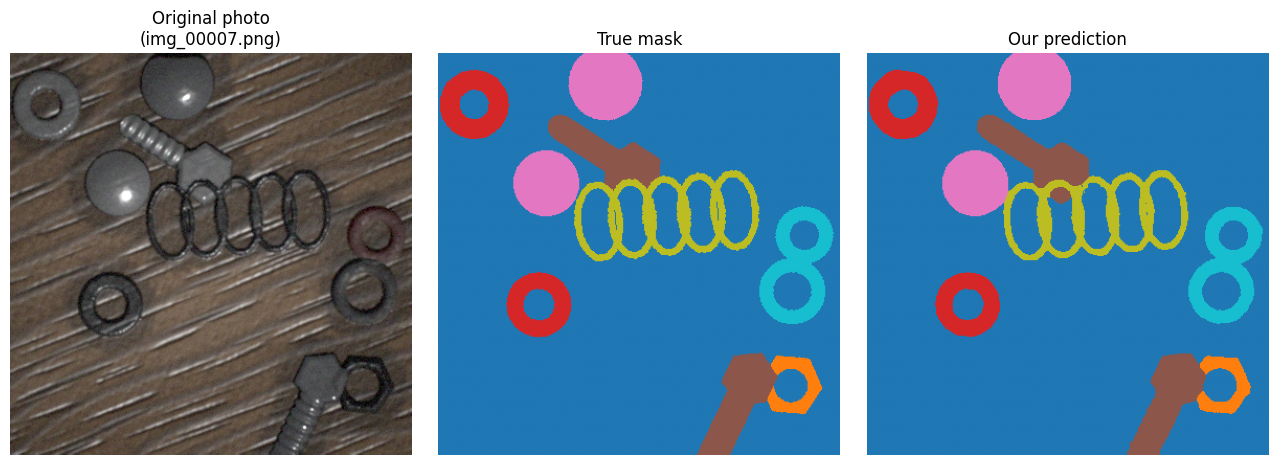

In [15]:
sample_id = VAL_IDS[0]
sample_img = np.array(Image.open(f"{TRAIN_IMG_DIR}/{sample_id}").convert("RGB"))
sample_gt = load_label_from_disk(sample_id, split="train")
sample_pred = val_preds_final[VAL_IDS.index(sample_id)]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(sample_img)
axes[0].set_title(f"Original photo\n({sample_id})")
axes[1].imshow(sample_gt, cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
axes[1].set_title("True mask")
axes[2].imshow(sample_pred, cmap="tab10", vmin=0, vmax=N_CLASSES - 1)
axes[2].set_title("Our prediction")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Submission

In [16]:
def build_submission_keys():
    """Builds the exact same rows sample_submission.csv would have contained --
    one row per test image per class -- directly from metadata.csv.
    sample_submission.csv itself is only Kaggle's leaderboard-registration file;
    it isn't needed to produce a correct submission, so we don't read it at all."""
    test_ids = sorted(meta[meta.split == "test"].id)
    rows = [{"ImageId_ClassId": f"{i}_{c}", "EncodedPixels": ""} for i in test_ids for c in CLASSES]
    return pd.DataFrame(rows)


def write_submission(pred_label_by_id, out_path):
    """pred_label_by_id: dict of test_image_id -> 384x384 uint8 label map (0-6)."""
    sub = build_submission_keys()
    parsed = sub["ImageId_ClassId"].apply(split_image_class_id)
    img_ids = parsed.apply(lambda t: t[0])
    classes = parsed.apply(lambda t: t[1])

    encoded = []
    for img_id, c in zip(img_ids, classes):
        lab = pred_label_by_id[img_id]
        m = (lab == CLASS_ID[c])
        encoded.append(rle_encode(m) if m.any() else "")
    sub["EncodedPixels"] = encoded
    sub.to_csv(out_path, index=False)
    return sub


In [17]:
test_ids = sorted(meta[meta.split == "test"].id)
print(f"Predicting on {len(test_ids)} test images...")

final_preds = {}
for img_id in test_ids:
    img = np.array(Image.open(f"{TEST_IMG_DIR}/{img_id}").convert("RGB")).astype(np.float32) / 255.0
    t = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).float().to(DEVICE)
    probs = tta_predict(model, t)
    pred = probs.argmax(1).squeeze(0).cpu().numpy().astype(np.uint8)
    final_preds[img_id] = clean_small_components(pred)

sub_path = f"{OUT_DIR}/submission.csv"
sub_df = write_submission(final_preds, sub_path)
print(f"Wrote {sub_path}  ({len(sub_df)} rows)")


Predicting on 500 test images...
Wrote /kaggle/working/submission.csv  (3000 rows)


In [18]:
def validate_submission(sub_df, size=SIZE):
    expected = build_submission_keys()
    assert list(sub_df["ImageId_ClassId"]) == list(expected["ImageId_ClassId"]), \
        "Row order/keys don't match the expected test image/class keys"

    max_pixel = size * size
    for rle in sub_df["EncodedPixels"]:
        if not isinstance(rle, str) or not rle.strip():
            continue
        vals = [int(x) for x in rle.split()]
        assert len(vals) % 2 == 0, f"Odd number of values: {rle[:50]}"
        starts, lengths = vals[0::2], vals[1::2]
        assert all(s >= 1 for s in starts), f"Non-positive start: {rle[:50]}"
        assert all(l > 0 for l in lengths), f"Non-positive length: {rle[:50]}"
        ends = [s + l - 1 for s, l in zip(starts, lengths)]
        assert max(ends) <= max_pixel, f"Run extends past {max_pixel}: {rle[:50]}"
        pairs = sorted(zip(starts, ends))
        for (s1, e1), (s2, e2) in zip(pairs, pairs[1:]):
            assert s2 > e1, f"Overlapping runs: {rle[:80]}"
        m = rle_decode(rle, size)
        assert rle_decode(rle_encode(m), size).tobytes() == m.tobytes(), f"Round-trip mismatch: {rle[:50]}"
    print(f"validate_submission: PASSED  ({len(sub_df)} rows)")